# アルゴリズム論Ⅱ 

## 第2回：二分法での計算

このノートブックでは、中間値の定理を利用した解の探索の方法である二分法について学びます。シンプルな計算ですが、確実な収束が期待できます。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import math
import warnings
import logging

# 警告・フォント検索ログの抑制
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# グラフ描画のスタイル設定
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 日本語フォント対策（japanize_matplotlib またはシステム内のフォントを自動検出）
try:
    import japanize_matplotlib
except ImportError:
    candidate_fonts = ['Noto Sans CJK JP', 'IPAexGothic', 'IPAGothic', 'Hiragino Sans', 'Yu Gothic', 'Meiryo']
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    found_font = next((f for f in candidate_fonts if f in available_fonts), None)
    if found_font:
        plt.rcParams['font.family'] = found_font

plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止


---
## 1. 方程式 $x^3 - 3x + 1 = 0$ の実数解

まずは、対象とする3次方程式のグラフを描画して、解（$y=0$ となる $x$）がどこにあるかを確認してみましょう。


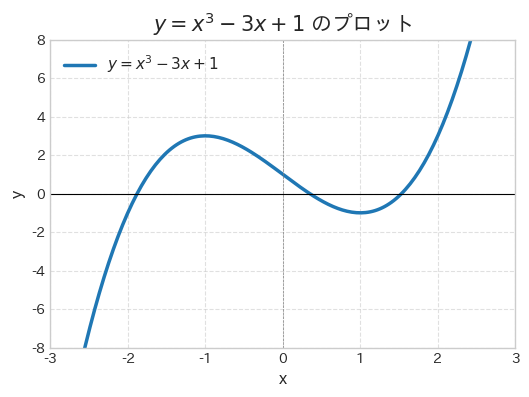

In [106]:
# データの作成
x = np.linspace(-3, 3, 200)
y = x**3 - 3*x + 1

# グラフのサイズと設定
plt.figure(figsize=(6, 4))
plt.plot(x, y, label="$y = x^3 - 3x + 1$", color="tab:blue", linewidth=2.5)

# x 軸、y 軸（基準線）とグリッド
plt.axhline(0, color="black", linestyle="-",  linewidth=0.8)
plt.axvline(0, color="gray",  linestyle="--", linewidth=0.5)
plt.grid(True, linestyle="--", alpha=0.6)

# 軸ラベルとタイトルの設定
plt.title("$y = x^3 - 3x + 1$ のプロット", fontsize=15)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.xlim(-3, 3)
plt.ylim(-8, 8)
plt.legend(loc="upper left", fontsize=11)
plt.show()

グラフを見ると、$x$ 軸（$y=0$）と交わる点が **3箇所** あることが分かります：
1. $x \approx -1.8$ 付近（$-2$ と $-1$ の間）
2. $x \approx 0.3$ 付近（$0$ と $1$ の間）
3. $x \approx 1.53$ 付近（$1$ と $2$ の間）

実は、3次方程式の解の公式（カルダノの公式）を使うと、厳密解は次のような非常に複雑な形になります：

$$\begin{aligned} 
x_1 &= \sqrt[3]{-\frac{1}{2} + \frac{\sqrt{3}}{2}i} \;+\; \sqrt[3]{-\frac{1}{2} - \frac{\sqrt{3}}{2}i} \\ 
x_2 &= \omega \sqrt[3]{-\frac{1}{2} + \frac{\sqrt{3}}{2}i} \;+\; \omega^2 \sqrt[3]{-\frac{1}{2} - \frac{\sqrt{3}}{2}i} \\ 
x_3 &= \omega^2 \sqrt[3]{-\frac{1}{2} + \frac{\sqrt{3}}{2}i} \;+\; \omega \sqrt[3]{-\frac{1}{2} - \frac{\sqrt{3}}{2}i} 
\end{aligned}$$
*(※ $\omega = \frac{-1 + \sqrt{3}i}{2}$ は 1 の虚数 3乗根)*

実数解であるにもかかわらず計算の途中に虚数 $i$ が登場し（還元不能）、手計算で具体的な数値を求めるのは極めて困難です。
そこで活躍するのが、コンピュータによる **数値解法（二分法）** です。


---
## 2. 二分法の原理（中間値の定理）

二分法（Bisection Method）は、数学の **中間値の定理** を利用した解の探索方法です。

> **📐 中間値の定理**  
> 連続な関数 $f(x)$ において、区間の両端での符号が異なる（異符号）、すなわち
> $$ f(a) \cdot f(b) < 0 $$
> であるならば、区間 $(a, b)$ の間に $f(c) = 0$ となる解 $c$ が**必ず少なくとも1つ存在する**。

### 二分法のアルゴリズム（手順）
1. 解を挟み込む初期区間 $[a, b]$ を決める（$f(a)$ と $f(b)$ が異符号）。
2. 中点 $c = \frac{a + b}{2}$ を計算する。
3. $f(a)$ と $f(c)$ の符号を調べる：
   - $f(a) \cdot f(c) < 0$ なら、解は左半分 $[a, c]$ にある $\rightarrow b$ を $c$ に更新する。
   - そうでなければ、解は右半分 $[c, b]$ にある $\rightarrow a$ を $c$ に更新する。
4. 区間の幅が十分に小さくなるまで、2 と 3 を繰り返す。

1回繰り返すごとに区間の幅は半分（$\frac{1}{2}$）になります。20回繰り返すと、誤差は $\frac{1}{2^{20}} \approx \frac{1}{1,000,000}$（100万分の1以下）まで縮小します。


---
## 3. 二分法の実装：$x \approx 1.53$ の解を求める

まずは例として、区間 $[1, 2]$ にある正の実数解を求めてみましょう。
- $f(1) = 1^3 - 3(1) + 1 = -1 < 0$
- $f(2) = 2^3 - 3(2) + 1 = 3 > 0$

両端で符号が異なっているので、区間 $[1, 2]$ に解が存在することが保証されます。


In [ ]:
# 対象の関数
def f(x):
    return x**3 - 3*x + 1

# 初期区間の設定 [a, b]
a = 1.0
b = 2.0

print(f"初期状態: a = {a:.4f} (f(a) = {f(a):+.4f}),  b = {b:.4f} (f(b) = {f(b):+.4f})")
print("-" * 65)

# 二分法のループ（20回反復）
for step in range(1, 21):
    c = (a + b) / 2.0
    fc = f(c)
    
    # 5ステップごと、および最初の数回を表示
    if step <= 5 or step % 5 == 0:
        print(f"Step {step:2d}: a = {a:.6f}, b = {b:.6f} --> 中点 c = {c:.6f}, f(c) = {fc:+.4e}")
    
    # 区間の更新
    if f(a) * fc < 0:
        b = c  # 解は左半分にある
    else:
        a = c  # 解は右半分にある

print("-" * 65)
print(f"求まった近似解: x = {c:.8f}")
print(f"そのときの f(x) の値: {f(c):.4e}")


---
## 4. 【演習】別の解を二分法で求めてみよう！

先ほどのグラフで確認した通り、方程式 $x^3 - 3x + 1 = 0$ には他に2つの解があります：
- **負の解**: 
- **もう1つの正の解**:

以下のプログラムの中で、初期区間 `a` と `b` の値を適切に変更して、**負の解（または、もう1つの正の解）** を求めてみましょう。


In [ ]:
# 対象の関数
def f(x):
    return x**3 - 3*x + 1

# 初期区間の設定 [a, b]
a = ??
b = ??

print(f"初期状態: a = {a:.4f} (f(a) = {f(a):+.4f}),  b = {b:.4f} (f(b) = {f(b):+.4f})")
print("-" * 65)

# 二分法のループ（20回反復）
for step in range(1, 21):
    c = (a + b) / 2.0
    fc = f(c)
    
    # 5ステップごと、および最初の数回を表示
    if step <= 5 or step % 5 == 0:
        print(f"Step {step:2d}: a = {a:.6f}, b = {b:.6f} --> 中点 c = {c:.6f}, f(c) = {fc:+.4e}")
    
    # 区間の更新
    if f(a) * fc < 0:
        b = c  # 解は左半分にある
    else:
        a = c  # 解は右半分にある

print("-" * 65)
print(f"求まった近似解: x = {c:.8f}")
print(f"そのときの f(x) の値: {f(c):.4e}")

---
## 5. 実用事例 1：
## 【力学・弾道シミュレーション】空気抵抗がある場合の射撃角度探索

### 🎯 目標
> **初速 $v_0 = 60\,\text{m/s}$ で発射し、$160\,\text{m}$ 先のターゲットに命中させたい。発射角度 $\theta$ は何度にすればよいか？**

---

### 📖 参考：空気抵抗を無視した場合の「解析解（手計算）」
高校物理で学ぶように、空気抵抗を無視できる理想的な放物運動では、水平到達距離 $X$ の公式が存在します：

$$ X = \frac{v_0^2 \sin(2\theta)}{g} $$

この式から、ターゲット距離 $X = 160\,\text{m}$ に命中させる角度 $\theta$ は、逆算（手計算）で直接求めることができます：

$$ \sin(2\theta) = \frac{g X}{v_0^2} \implies \theta = \frac{1}{2} \arcsin\left(\frac{g X}{v_0^2}\right) $$

数値を代入（$v_0 = 60\,\text{m/s}$, $g = 9.81\,\text{m/s}^2$, $X = 160\,\text{m}$）すると：
$$ \frac{g X}{v_0^2} = \frac{9.81 \times 160}{60^2} = \frac{1569.6}{3600} = 0.436 $$
$$ \theta = \frac{1}{2} \arcsin(0.436) \approx \mathbf{12.92^\circ} \quad (\text{または高射角 } 90^\circ - 12.92^\circ = 77.08^\circ) $$


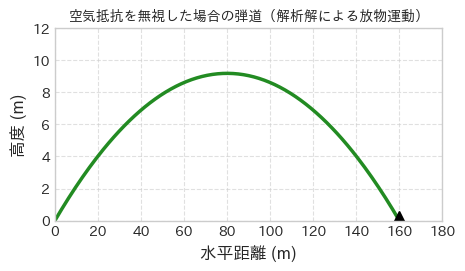

In [104]:
import math
import matplotlib.pyplot as plt
import numpy as np

# 条件設定
target = 160.0  # 目標距離 (m)
v0 = 60.0  # 初速 (m/s)
g = 9.81  # 重力加速度 (m/s^2)

# 空気抵抗なしの解析解（発射角度）の計算: 約 12.92度
theta_no_drag = 0.5 * math.degrees(math.asin((g * target) / (v0**2)))
theta_nd_rad = math.radians(theta_no_drag)

# 放物線の軌道計算
x_nd = np.linspace(0, target, 200)
# 軌道方程式: y = x * tan(theta) - (g * x^2) / (2 * v0^2 * cos^2(theta))
y_nd = x_nd * math.tan(theta_nd_rad) - (g * x_nd**2) / (
    2 * (v0**2) * (math.cos(theta_nd_rad) ** 2)
)

# 解析解のグラフ描画
plt.figure(figsize=(5, 2.5))
plt.plot(x_nd, y_nd, color="forestgreen", linewidth=2.5)
plt.plot(target, 0, "k^", markersize=14)
plt.title("空気抵抗を無視した場合の弾道（解析解による放物運動）", fontsize=10)
plt.xlabel("水平距離 (m)", fontsize=12)
plt.ylabel("高度 (m)", fontsize=12)
plt.xlim(0, 180)
plt.ylim(0, 12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

---
### 🌪️ 現実の世界：空気抵抗がある場合
しかし、現実の大気中では**速度の2乗に比例する空気抵抗**（抗力 $F_d = -k v^2$）が強く働きます。
空気抵抗が加わると、運動方程式が非線形連立微分方程式となり、**手計算で到達距離を表す公式（解析解）を導くことが数学的に不可能**になります。

そのため、コンピュータで微小時間 $\Delta t$ ごとに位置と速度を追跡する数値シミュレータを作り、**二分法**を用いて $160\,\text{m}$ 先に命中する角度を逆算します。


In [ ]:
# 空気抵抗を考慮した弾道シミュレータ
def simulate_trajectory(theta_deg, v0=60.0, k=0.004, g=9.81, dt=0.005):
    """
    発射角度 theta_deg (度) を受け取り、着弾距離 (m) と軌道座標 (x, y) を返す
    """
    theta = math.radians(theta_deg)
    vx = v0 * math.cos(theta)
    vy = v0 * math.sin(theta)
    x, y = 0.0, 0.0
    
    traj_x = [x]
    traj_y = [y]
    
    while y >= 0:
        v = math.hypot(vx, vy)
        ax = -k * v * vx
        ay = -g - k * v * vy
        
        vx += ax * dt
        vy += ay * dt
        x += vx * dt
        y += vy * dt
        
        traj_x.append(x)
        traj_y.append(y)
        
    # 地面 (y=0) を通過した直前・直後で線形補間して正確な着弾距離を計算
    if len(traj_x) >= 2 and (traj_y[-1] - traj_y[-2]) != 0:
        fraction = -traj_y[-2] / (traj_y[-1] - traj_y[-2])
        landing_x = traj_x[-2] + fraction * (traj_x[-1] - traj_x[-2])
    else:
        landing_x = x
        
    return landing_x, traj_x, traj_y

print("✅ 弾道シミュレータ simulate_trajectory() を準備しました。")

### 【ステップ1：手動でパラメータを手探りしてみよう】
まずは以下のセルの角度 `test_angle` を手作業で何度か書き換えて実行し、着弾距離が **$160\,\text{m}$** 付近になる角度を探してみてください！
（例: 10度、40度、30度、25度...など）


In [ ]:
# 角度を手動で変えて試してみよう！
test_angle = 40.0  # ← この数値を色々変えて実行してみてください

landing_x, tx, ty = simulate_trajectory(test_angle)
plt.figure(figsize=(5, 2.5))
plt.plot(tx, ty, "b-", linewidth=2, label=f"発射角 {test_angle:.1f}°")
plt.plot(160.0, 0, "k^", markersize=16, label="目標ターゲット (160m)")
plt.axvline(160.0, color="gray", linestyle="--", alpha=0.5)
plt.title( f"発射角度 {test_angle:.1f}° の弾道 (着弾: {landing_x:.1f} m)")
plt.xlabel("水平距離 (m)", fontsize=11)
plt.ylabel("高度 (m)", fontsize=11)
plt.xlim(0, 200)
plt.ylim(0, 100)
plt.legend(loc="upper right")
plt.show()

### 【ステップ2：二分法で自動的に角度を突き止める】
皆さんが手動で試したとき、
- 「10度だと手前すぎる（$160\,\text{m}$ 未満）」
- 「40度だと飛びすぎる（$160\,\text{m}$ より遠い）」
- 「じゃあ間の角度を試してみよう」
と考えたはずです。

**これこそが、まさに二分法の考え方そのものです！**  
この手探りの試行錯誤を、コンピュータに二分法で自動実行させてみましょう。


In [ ]:
# 目標距離
target = 160.0

# 目標とのズレ（残差）を計算する関数: これが 0 になれば命中
def error(theta):
    dist, _, _ = simulate_trajectory(theta)
    return dist - target

# 初期区間: 10度（手前）〜 40度（飛びすぎ）
angle_a = 10.0
angle_b = 40.0

print(f"初期探索範囲: [{angle_a}度, {angle_b}度]")
print("-" * 65)

# 二分法の実行
for step in range(1, 16):
    mid_angle = (angle_a + angle_b) / 2.0
    err_mid = error(mid_angle)
    
    print(f"Step {step:2d}: 角度 {mid_angle:.4f}度 --> 着弾ズレ: {err_mid:+.4f} m")
    
    # 誤差が 1mm (0.001m) 未満になったら終了
    if abs(err_mid) < 0.001:
        break
        
    if error(angle_a) * err_mid < 0:
        angle_b = mid_angle
    else:
        angle_a = mid_angle

optimal_angle = mid_angle
final_dist, opt_x, opt_y = simulate_trajectory(optimal_angle)

# 空気抵抗なしの場合の解析解（手計算値）
theta_no_drag = 0.5 * math.degrees(math.asin((9.81 * target) / (60.0**2)))

print("-" * 65)
print(f"🎯 計算された最適発射角度: {optimal_angle:.3f} 度")
print(f"最終着弾距離: {final_dist:.3f} m (目標との誤差: {final_dist - target:.4f} m)")
print(f"（参考）空気抵抗を無視した解析解: {theta_no_drag:.3f} 度")
print(f"※ 空気抵抗で弾が減速するため、真空中の解析解より約 {optimal_angle - theta_no_drag:.1f}度 高く撃ち出す必要があることが分かります。")


In [ ]:
# 命中した弾道の可視化
plt.figure(figsize=(10, 5))

# 1. 空気抵抗なしの理論軌道（解析解: 12.06度）
theta_nd_rad = math.radians(theta_no_drag)
x_nd = np.linspace(0, target, 100)
# 放物線の軌道方程式: y = x * tan(theta) - (g * x^2) / (2 * v0^2 * cos^2(theta))
y_nd = x_nd * math.tan(theta_nd_rad) - (9.81 * x_nd**2) / (2 * (60.0**2) * (math.cos(theta_nd_rad)**2))
plt.plot(x_nd, y_nd, '--', color='forestgreen', linewidth=2, label=f'空気抵抗なし (解析解: {theta_no_drag:.2f}°)')

# 2. 初期の試行（10度と40度）
_, x10, y10 = simulate_trajectory(10.0)
_, x40, y40 = simulate_trajectory(40.0)
plt.plot(x10, y10, ':', color='gray', label='空気抵抗あり: 10度 (手前に落下)')
plt.plot(x40, y40, ':', color='steelblue', label='空気抵抗あり: 40度 (飛びすぎ)')

# 3. 二分法で求めた最適軌道（空気抵抗あり: 20.17度）
plt.plot(opt_x, opt_y, 'r-', linewidth=2.5, label=f'空気抵抗あり (二分法の解: {optimal_angle:.2f}°)')

# ターゲット（160m）の表示
plt.plot(160.0, 0, 'k^', markersize=20, label='目標ターゲット (160m)')
plt.title("弾道シミュレーション: 空気抵抗の有無による弾道と発射角度の比較", fontsize=14)
plt.xlabel("水平距離 (m)", fontsize=12)
plt.ylabel("高度 (m)", fontsize=12)
plt.ylim(bottom=0)
plt.legend(loc="upper right", fontsize=10.5)
plt.show()


---
## 6. 実用事例 2：
## 【金融・ビジネス】投資の採算性を測る「内部収益率（IRR）」

ビジネスや投資の世界で極めて重要な指標が **IRR（Internal Rate of Return: 内部収益率）** です。
「この事業や設備投資は、年利何％の利回りに相当するのか？」を評価するために使われます。

### 正味現在価値（NPV）とIRR
いま、初期投資額として $1,000$ 万円を支出し、その後 1〜5 年目に回収金が得られるとします。
割引率（年利回り）を $r$ としたときの **正味現在価値（NPV: Net Present Value）** は次式で計算されます：

$$ \text{NPV}(r) = -1000 + \frac{250}{1+r} + \frac{320}{(1+r)^2} + \frac{380}{(1+r)^3} + \frac{420}{(1+r)^4} + \frac{280}{(1+r)^5} $$

- **IRRとは**: 正味現在価値がちょうどゼロになる割引率 $r^*$（つまり $\text{NPV}(r^*) = 0$ となる年利）のことです。

この式は $r$ に関する5次方程式なので、手計算で解く公式はありません。
しかし、金利 $r$ が高くなるほど将来のお金の価値は下がるため、$\text{NPV}(r)$ は $r$ について綺麗に右肩下がりのグラフ（単調減少）になります。
したがって、二分法を使えば100%確実に利回り $r$ を求めることができます！


In [ ]:
# キャッシュフロー（単位: 万円）
# 0年目: -1000万, 1年目: 250万, 2年目: 320万, 3年目: 380万, 4年目: 420万, 5年目: 280万
cash_flows = [-1000, 250, 320, 380, 420, 280]

def npv(r):
    """割引率 r における正味現在価値 NPV を計算"""
    total = 0.0
    for t, c in enumerate(cash_flows):
        total += c / ((1.0 + r)**t)
    return total

# 探索区間: 年利 0% (r=0.0) 〜 年利 50% (r=0.50)
r_a = 0.0
r_b = 0.50

print(f"NPV(0%)  = {npv(r_a):+8.2f} 万円 (>0: 黒字)")
print(f"NPV(50%) = {npv(r_b):+8.2f} 万円 (<0: 割引が大きすぎて赤字)")
print("-" * 65)

# 二分法の実行
for step in range(1, 21):
    r_mid = (r_a + r_b) / 2.0
    val = npv(r_mid)
    
    if npv(r_a) * val < 0:
        r_b = r_mid
    else:
        r_a = r_mid

irr = r_mid
print(f"🎯 計算された内部収益率 (IRR): {irr * 100:.3f} % (年利 約{irr*100:.1f}%)")
print(f"検算: NPV(IRR) = {npv(irr):.4e} 万円")


In [ ]:
# NPV 曲線のプロット
rates = np.linspace(0.0, 0.40, 100)
npv_vals = [npv(r) for r in rates]

plt.figure(figsize=(8, 4.5))
plt.plot(rates * 100, npv_vals, 'b-', linewidth=2.5, label='NPV (正味現在価値)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot(irr * 100, 0, 'ro', markersize=8, label=f'IRR = {irr*100:.2f}% (NPV=0)')

plt.title("投資プロジェクトの NPV 曲線と内部収益率 (IRR)", fontsize=14)
plt.xlabel("割引率・年利 r (%)", fontsize=12)
plt.ylabel("正味現在価値 NPV (万円)", fontsize=12)
plt.legend(fontsize=11)
plt.show()


---
## 7. 収束のスピード比較：二分法 vs ニュートン法

方程式の解を求めるアルゴリズムには、二分法のほかに **ニュートン法（Newton-Raphson Method）** があります。
方程式 $f(x) = x^2 - 2 = 0$ の解（$\sqrt{2} \approx 1.41421356...$）を求める2つの方法で、収束速度の違いをプロットして比較してみましょう。

* **二分法 (Bisection Method)**: **一次収束**（ステップごとに誤差が約 $1/2$ になる）
* **ニュートン法 (Newton-Raphson Method)**: **二次収束**（ステップごとに正しい桁数が約2倍に増える）


In [ ]:
target = math.sqrt(2)

# 1. 二分法
a, b = 1.0, 2.0
errors_bisection = []
for _ in range(20):
    mid = (a + b) / 2.0
    errors_bisection.append(abs(mid - target))
    if mid**2 - 2 > 0:
        b = mid
    else:
        a = mid

# 2. ニュートン法: x_{k+1} = x_k - (x_k^2 - 2) / (2 * x_k)
x_val = 2.0
errors_newton = []
for _ in range(20):
    errors_newton.append(abs(x_val - target))
    x_val = x_val - (x_val**2 - 2) / (2 * x_val)

# 誤差の推移を対数スケールでグラフ描画
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, 21), errors_bisection, label='二分法 (一次収束: 確実に半減)', marker='o')
plt.semilogy(range(1, 21), errors_newton, label='ニュートン法 (二次収束: 爆発的に収束)', marker='s')
plt.title("収束スピードの比較 (対数スケール)", fontsize=14)
plt.xlabel("反復回数 (Step)", fontsize=12)
plt.ylabel("真値との誤差 |x - √2|", fontsize=12)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=11)
plt.show()


### 二分法とニュートン法の比較まとめ

| 特徴 | 二分法 (Bisection Method) | ニュートン法 (Newton-Raphson) |
| :--- | :--- | :--- |
| **収束の速さ** | 1次収束（ゆっくり確実に進む） | **2次収束（驚異的に速い）** |
| **導関数 $f'(x)$** | **不要（関数の値だけでOK）** | 必須（微分できない関数には使えない） |
| **収束の確実性** | **絶対確実（解を挟めば100%収束）** | 初期値が悪いと発散・振動して失敗する |
| **反復回数の予測** | **事前に何回で解けるか正確に分かる** | 事前には分からない |

> 💡 **現代の現場で使われている「ブレント法（Brent's Method）」について**  
> 「二分法の絶対に失敗しない安心感」と「ニュートン法などの圧倒的な計算スピード」、この両方を良いとこ取りできないでしょうか？  
> それを実現したのが **ブレント法** です。  
> ブレント法は「普段は高速な方法で一気に解に近づき、雲行きが怪しくなったら自動的に二分法に切り替える」という賢い仕組みを持っており、Excelのゴールシークや科学計算ソフトウェアの標準アルゴリズムとして広く使われています。
